In [12]:
# ============================================================
# CELDA 3: Carga y parseo de los archivos .net (formato Pajek)
# ============================================================
# Los archivos .net son formato Pajek, que tiene dos secciones:
#   *vertices N  → lista de nodos
#   *edges       → lista de aristas (pares de nodos)
# NetworkX tiene un lector nativo para este formato.

import os
import re
import networkx as nx

data_path = os.path.expanduser("~/CN/A2_synthetic_networks")

# Diccionario: prr_value -> grafo
networks = {}

files = sorted([f for f in os.listdir(data_path) if f.endswith('.net')])

for fname in files:
    # Extraemos el valor de prr del nombre del archivo
    match = re.search(r'prr_([\d.]+)_prs', fname)
    if match:
        prr = float(match.group(1))
        fpath = os.path.join(data_path, fname)
        G = nx.read_pajek(fpath)
        # Convertimos a grafo no dirigido simple (Pajek puede dar MultiGraph)
        G = nx.Graph(G)
        networks[prr] = G

# Verificación
print(f"Redes cargadas: {len(networks)}")
print(f"\nEjemplo — prr=0.04:")
G_ex = networks[0.04]
print(f"  Nodos: {G_ex.number_of_nodes()}")
print(f"  Aristas: {G_ex.number_of_edges()}")
print(f"  Nodos ejemplo: {list(G_ex.nodes())[:5]}")

Redes cargadas: 51

Ejemplo — prr=0.04:
  Nodos: 300
  Aristas: 1102
  Nodos ejemplo: ['1', '2', '3', '4', '5']


In [13]:
# ============================================================
# CELDA 4: Ground truth — partición real de los nodos
# ============================================================
# El enunciado dice:
#   Nodos  1- 60  → bloque 1
#   Nodos 61-120  → bloque 2
#   Nodos 121-180 → bloque 3
#   Nodos 181-240 → bloque 4
#   Nodos 241-300 → bloque 5
#
# Los nodos son strings ('1', '2', ..., '300') según vimos en Celda 3.
# Creamos un diccionario: nodo -> comunidad_real

ground_truth = {}
for i in range(1, 301):
    node = str(i)
    community = (i - 1) // 60  # 0,1,2,3,4
    ground_truth[node] = community

# Verificación
print("Ground truth (primeros y últimos de cada bloque):")
checkpoints = [1, 60, 61, 120, 121, 180, 181, 240, 241, 300]
for i in checkpoints:
    print(f"  Nodo {i:>3} → bloque {ground_truth[str(i)]}")

Ground truth (primeros y últimos de cada bloque):
  Nodo   1 → bloque 0
  Nodo  60 → bloque 0
  Nodo  61 → bloque 1
  Nodo 120 → bloque 1
  Nodo 121 → bloque 2
  Nodo 180 → bloque 2
  Nodo 181 → bloque 3
  Nodo 240 → bloque 3
  Nodo 241 → bloque 4
  Nodo 300 → bloque 4


In [14]:
# ============================================================
# CELDA 5: Aplicar Infomap, Louvain y Leiden a todas las redes
# ============================================================
# Usaremos igraph para los 3 algoritmos porque:
#   - Infomap está nativo en igraph
#   - Louvain está nativo en igraph (community_multilevel)
#   - Leiden requiere leidenalg + igraph
#
# Flujo para cada red:
#   1. Convertir networkx -> igraph
#   2. Aplicar cada algoritmo
#   3. Guardar: nº comunidades, modularity, y partición (dict nodo->comunidad)

import igraph as ig
import leidenalg
import numpy as np

def nx_to_igraph(G_nx):
    """Convierte un grafo NetworkX a igraph manteniendo el nombre de los nodos."""
    nodes = list(G_nx.nodes())
    node_index = {n: i for i, n in enumerate(nodes)}
    edges = [(node_index[u], node_index[v]) for u, v in G_nx.edges()]
    G_ig = ig.Graph(n=len(nodes), edges=edges)
    G_ig.vs["name"] = nodes  # guardamos el nombre original ('1','2',...)
    return G_ig, nodes

def partition_to_dict(membership, nodes):
    """Convierte lista de membresías igraph a dict {nodo: comunidad}."""
    return {nodes[i]: membership[i] for i in range(len(nodes))}

# Resultados: dict anidado
# results[algoritmo][prr] = {'n_communities': int, 'modularity': float, 'partition': dict}
results = {
    'infomap': {},
    'louvain': {},
    'leiden':  {}
}

prr_values = sorted(networks.keys())

print("Procesando redes...")
for prr in prr_values:
    G_nx = networks[prr]
    G_ig, nodes = nx_to_igraph(G_nx)

    # ── INFOMAP ──────────────────────────────────────────────
    # Minimiza la longitud de descripción del flujo de información
    # No maximiza modularity directamente, sino el "map equation"
    im = G_ig.community_infomap()
    results['infomap'][prr] = {
        'n_communities': len(im),
        'modularity':    G_ig.modularity(im.membership),
        'partition':     partition_to_dict(im.membership, nodes)
    }

    # ── LOUVAIN ──────────────────────────────────────────────
    # Maximiza la modularity de forma greedy jerárquica
    # community_multilevel es la implementación de Louvain en igraph
    lv = G_ig.community_multilevel()
    results['louvain'][prr] = {
        'n_communities': len(lv),
        'modularity':    G_ig.modularity(lv.membership),
        'partition':     partition_to_dict(lv.membership, nodes)
    }

    # ── LEIDEN ───────────────────────────────────────────────
    # Mejora de Louvain: garantiza comunidades bien conectadas
    # Usamos ModularityVertexPartition para maximizar modularity
    ld = leidenalg.find_partition(G_ig, leidenalg.ModularityVertexPartition)
    results['leiden'][prr] = {
        'n_communities': len(ld),
        'modularity':    G_ig.modularity(ld.membership),
        'partition':     partition_to_dict(ld.membership, nodes)
    }

print("✅ Hecho!")
print(f"\nEjemplo — prr=0.16:")
for algo in results:
    r = results[algo][0.16]
    print(f"  {algo:<10} comunidades={r['n_communities']}  Q={r['modularity']:.4f}")

Procesando redes...
✅ Hecho!

Ejemplo — prr=0.16:
  infomap    comunidades=5  Q=0.4588
  louvain    comunidades=5  Q=0.4576
  leiden     comunidades=5  Q=0.4588


In [15]:
# ============================================================
# CELDA 6: Jaccard Index, NMI y NVI para cada algoritmo y prr
# ============================================================
# Comparamos la partición encontrada vs ground truth.
#
# - Jaccard Index: fracción de pares de nodos correctamente 
#   asignados (misma comunidad en ambas particiones) sobre
#   el total de pares que comparten comunidad en alguna de ellas.
#   IMPORTANTE: no confundir con Jaccard de conjuntos de nodos.
#   Usamos la versión orientada a clustering (pares de nodos).
#
# - NMI (Normalized Mutual Information): mide cuánta información
#   comparten las dos particiones. 1=idénticas, 0=independientes.
#
# - NVI (Normalized Variation of Information): mide la distancia
#   entre particiones. 0=idénticas, 1=máxima diferencia.
#   NVI = 1 - NMI (con normalización aritmética)

from sklearn.metrics import normalized_mutual_info_score
from itertools import combinations
import numpy as np

def jaccard_partition(part1, part2):
    """
    Jaccard Index entre dos particiones basado en pares de nodos.
    Para cada par (i,j) contamos:
      a = ambos en la misma comunidad en part1 Y part2
      b = misma en part1, distinta en part2
      c = distinta en part1, misma en part2
    Jaccard = a / (a + b + c)
    """
    nodes = list(part1.keys())
    a = b = c = 0
    for u, v in combinations(nodes, 2):
        same1 = part1[u] == part1[v]
        same2 = part2[u] == part2[v]
        if same1 and same2:
            a += 1
        elif same1 and not same2:
            b += 1
        elif not same1 and same2:
            c += 1
    return a / (a + b + c) if (a + b + c) > 0 else 0.0

def compute_metrics(partition, ground_truth):
    """Calcula Jaccard, NMI y NVI entre una partición y la ground truth."""
    nodes = list(ground_truth.keys())
    
    labels_true = [ground_truth[n] for n in nodes]
    labels_pred = [partition[n] for n in nodes]
    
    nmi = normalized_mutual_info_score(labels_true, labels_pred, 
                                        average_method='arithmetic')
    nvi = 1 - nmi
    jac = jaccard_partition(partition, ground_truth)
    
    return {'jaccard': jac, 'nmi': nmi, 'nvi': nvi}

# Calculamos métricas para todos los algoritmos y prr
# Jaccard es O(N²) así que puede tardar ~1 min
print("Calculando métricas (Jaccard puede tardar ~1 min)...")

metrics = {algo: {} for algo in results}

for algo in results:
    for prr in prr_values:
        partition = results[algo][prr]['partition']
        metrics[algo][prr] = compute_metrics(partition, ground_truth)
    print(f"  ✅ {algo} listo")

print("\nEjemplo — prr=0.16:")
for algo in metrics:
    m = metrics[algo][0.16]
    print(f"  {algo:<10} Jaccard={m['jaccard']:.4f}  NMI={m['nmi']:.4f}  NVI={m['nvi']:.4f}")

Calculando métricas (Jaccard puede tardar ~1 min)...
  ✅ infomap listo
  ✅ louvain listo
  ✅ leiden listo

Ejemplo — prr=0.16:
  infomap    Jaccard=1.0000  NMI=1.0000  NVI=0.0000
  louvain    Jaccard=0.9608  NMI=0.9684  NVI=0.0316
  leiden     Jaccard=1.0000  NMI=1.0000  NVI=0.0000


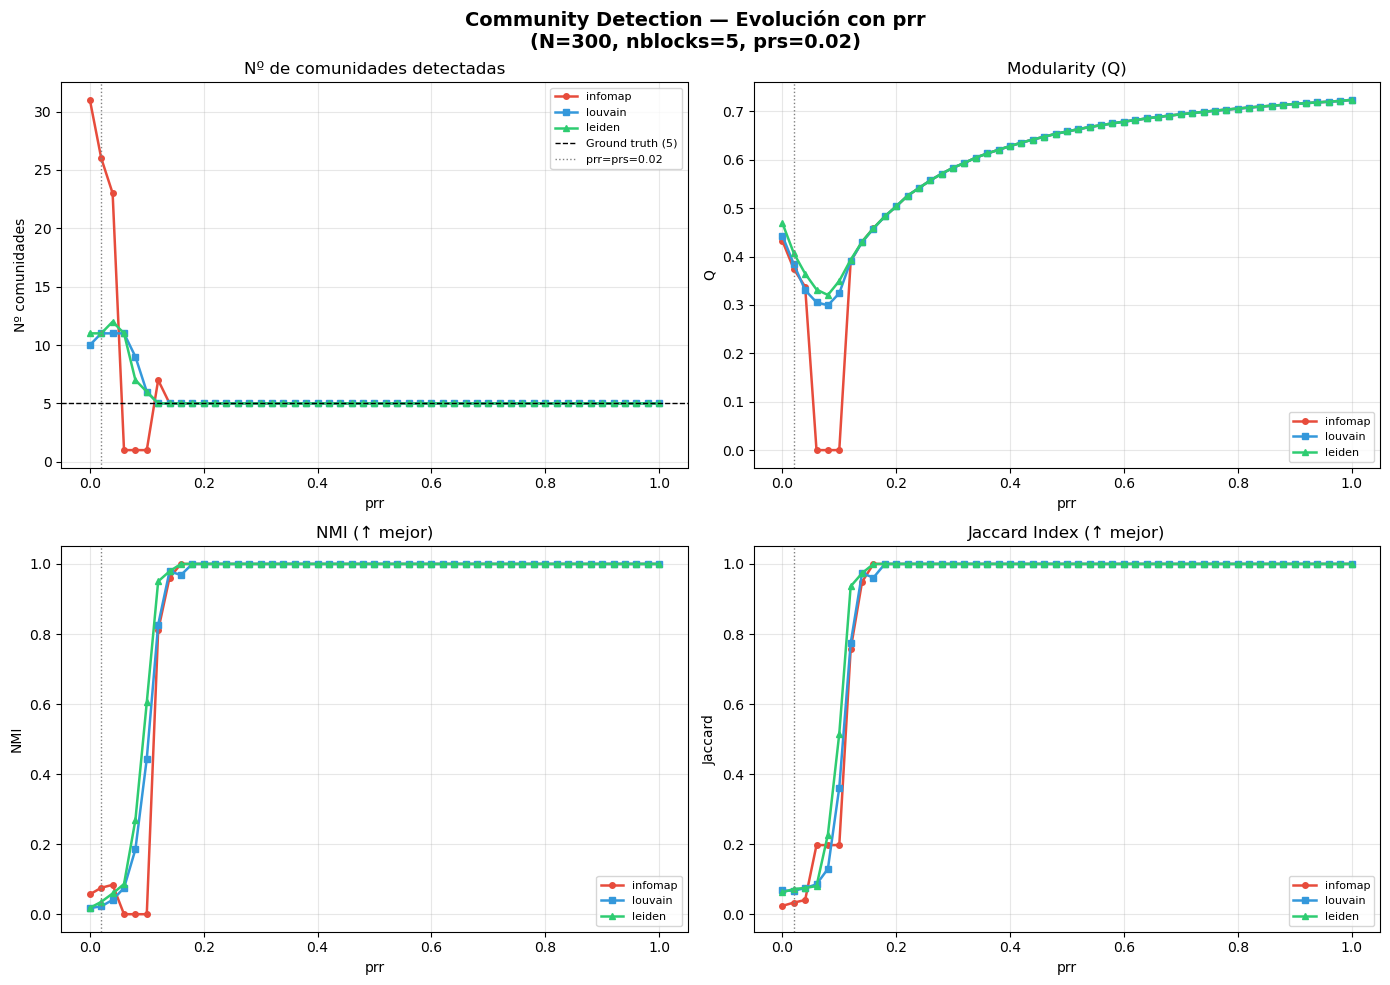

✅ Gráfica guardada en ~/CN/A2_evolution_metrics.png


In [16]:
# ============================================================
# CELDA 7: Evolución de métricas y nº comunidades con prr
# ============================================================
# 4 gráficas:
#   1. Nº de comunidades detectadas vs prr
#   2. Modularity (Q) vs prr
#   3. NMI vs prr  (1=perfecto, 0=malo)
#   4. Jaccard vs prr (1=perfecto, 0=malo)
# La línea vertical marca prr=prs=0.02 (red sin estructura clara)

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

algos   = ['infomap', 'louvain', 'leiden']
colors  = {'infomap': '#e74c3c', 'louvain': '#3498db', 'leiden': '#2ecc71'}
markers = {'infomap': 'o',       'louvain': 's',        'leiden': '^'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Community Detection — Evolución con prr\n(N=300, nblocks=5, prs=0.02)',
             fontsize=14, fontweight='bold')

prr_arr = np.array(prr_values)

# ── Panel 1: Número de comunidades ───────────────────────────
ax = axes[0, 0]
for algo in algos:
    y = [results[algo][p]['n_communities'] for p in prr_values]
    ax.plot(prr_arr, y, color=colors[algo], marker=markers[algo],
            markersize=4, label=algo, linewidth=1.8)
ax.axhline(5, color='black', linestyle='--', linewidth=1, label='Ground truth (5)')
ax.axvline(0.02, color='gray', linestyle=':', linewidth=1, label='prr=prs=0.02')
ax.set_title('Nº de comunidades detectadas')
ax.set_xlabel('prr'); ax.set_ylabel('Nº comunidades')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 2: Modularity ──────────────────────────────────────
ax = axes[0, 1]
for algo in algos:
    y = [results[algo][p]['modularity'] for p in prr_values]
    ax.plot(prr_arr, y, color=colors[algo], marker=markers[algo],
            markersize=4, label=algo, linewidth=1.8)
ax.axvline(0.02, color='gray', linestyle=':', linewidth=1)
ax.set_title('Modularity (Q)')
ax.set_xlabel('prr'); ax.set_ylabel('Q')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 3: NMI ─────────────────────────────────────────────
ax = axes[1, 0]
for algo in algos:
    y = [metrics[algo][p]['nmi'] for p in prr_values]
    ax.plot(prr_arr, y, color=colors[algo], marker=markers[algo],
            markersize=4, label=algo, linewidth=1.8)
ax.axvline(0.02, color='gray', linestyle=':', linewidth=1)
ax.set_title('NMI (↑ mejor)')
ax.set_xlabel('prr'); ax.set_ylabel('NMI')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 4: Jaccard ─────────────────────────────────────────
ax = axes[1, 1]
for algo in algos:
    y = [metrics[algo][p]['jaccard'] for p in prr_values]
    ax.plot(prr_arr, y, color=colors[algo], marker=markers[algo],
            markersize=4, label=algo, linewidth=1.8)
ax.axvline(0.02, color='gray', linestyle=':', linewidth=1)
ax.set_title('Jaccard Index (↑ mejor)')
ax.set_xlabel('prr'); ax.set_ylabel('Jaccard')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.expanduser('~/CN/A2_evolution_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada en ~/CN/A2_evolution_metrics.png")

Calculando layout (puede tardar ~30s)...
✅ Layout calculado


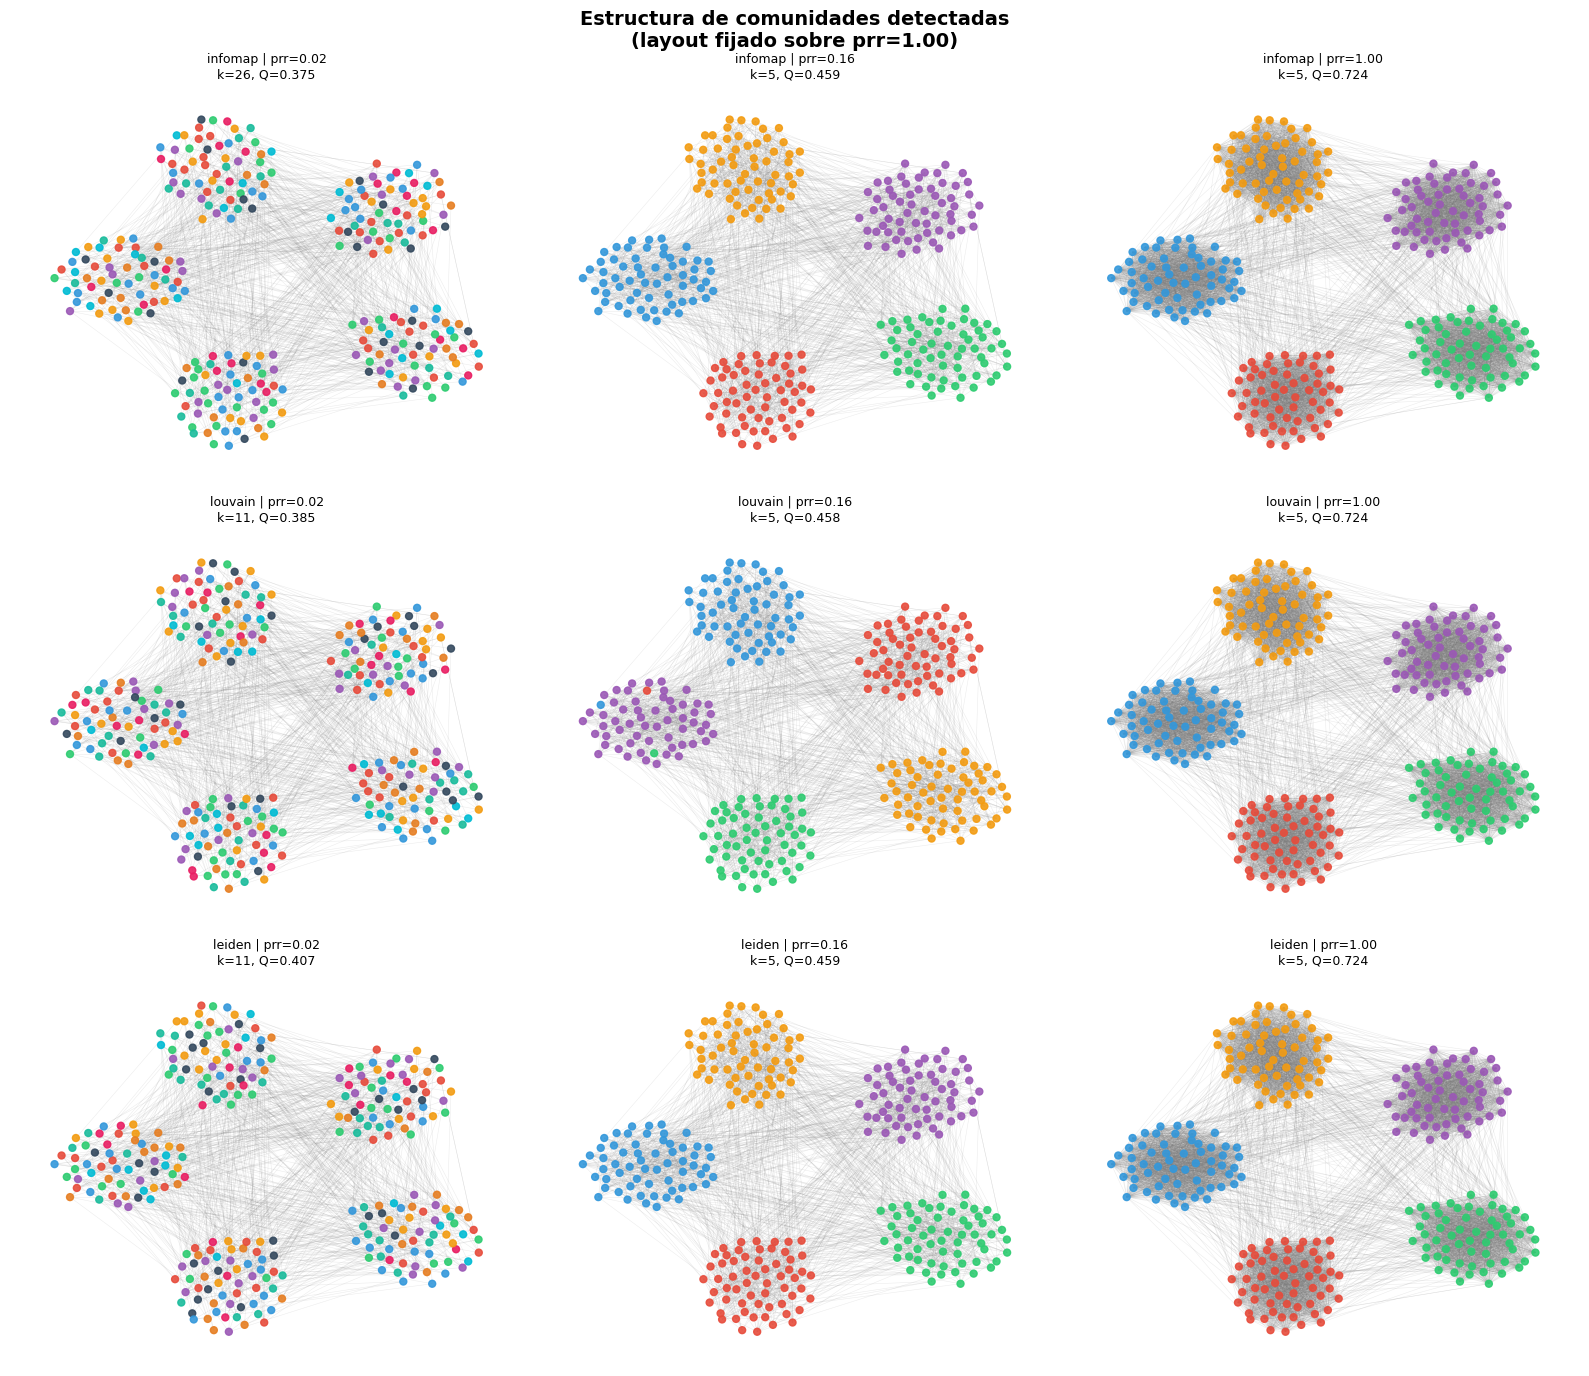

✅ Visualización guardada en ~/CN/A2_network_visualization.png


In [17]:
# ============================================================
# CELDA 8: Visualización color-coded para prr=0.02, 0.16, 1.00
# ============================================================
# - Calculamos el layout UNA VEZ sobre prr=1.00 (red más densa)
# - Reutilizamos esas posiciones para las otras dos redes
# - Una fila por algoritmo, una columna por prr
# - El color de cada nodo = comunidad asignada por ese algoritmo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Calcular layout sobre prr=1.00 ───────────────────────────
# Kamada-Kawai da layouts bonitos pero es lento para N=300.
# Usamos spring_layout (Fruchterman-Reingold) con seed fija.
print("Calculando layout (puede tardar ~30s)...")
G_layout = networks[1.00]
pos = nx.spring_layout(G_layout, seed=42, k=0.3, iterations=100)
print("✅ Layout calculado")

# Paleta de 5 colores para las comunidades (máximo ground truth = 5)
# Usamos un colormap discreto
PALETTE = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6',
           '#1abc9c', '#e67e22', '#34495e', '#e91e63', '#00bcd4']

def get_node_colors(partition, nodes, max_communities=None):
    """Devuelve lista de colores según la comunidad de cada nodo."""
    # Re-etiquetamos comunidades por tamaño (mayor primero) para consistencia visual
    from collections import Counter
    counts = Counter(partition.values())
    # Mapeamos id_comunidad_original -> id_comunidad_ordenada
    remap = {old: new for new, (old, _) in enumerate(counts.most_common())}
    return [PALETTE[remap[partition[n]] % len(PALETTE)] for n in nodes]

prr_plot  = [0.02, 0.16, 1.00]
algo_list = ['infomap', 'louvain', 'leiden']
nodes_ordered = list(networks[1.00].nodes())

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('Estructura de comunidades detectadas\n(layout fijado sobre prr=1.00)',
             fontsize=14, fontweight='bold')

for row, algo in enumerate(algo_list):
    for col, prr in enumerate(prr_plot):
        ax = axes[row, col]
        G  = networks[prr]
        
        partition  = results[algo][prr]['partition']
        node_colors = get_node_colors(partition, nodes_ordered)
        n_comm = results[algo][prr]['n_communities']
        Q      = results[algo][prr]['modularity']
        
        # Dibujamos aristas primero (gris fino)
        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15,
                               edge_color='gray', width=0.4)
        # Luego nodos coloreados
        nx.draw_networkx_nodes(G, pos, ax=ax,
                               node_color=node_colors,
                               node_size=25, alpha=0.9)
        
        ax.set_title(f'{algo} | prr={prr:.2f}\nk={n_comm}, Q={Q:.3f}',
                     fontsize=9)
        ax.axis('off')

# Etiquetas de filas
for row, algo in enumerate(algo_list):
    axes[row, 0].set_ylabel(algo, fontsize=11, fontweight='bold', labelpad=10)
    axes[row, 0].yaxis.label.set_visible(True)

plt.tight_layout()
plt.savefig(os.path.expanduser('~/CN/A2_network_visualization.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualización guardada en ~/CN/A2_network_visualization.png")

In [18]:
# ============================================================
# CELDA 9: Tabla resumen con todos los resultados
# ============================================================
# Útil para el informe: todos los valores de n_comm, Q, NMI, Jaccard
# para cada algoritmo y prr en un DataFrame organizado.

import pandas as pd

rows = []
for algo in algo_list:
    for prr in prr_values:
        r = results[algo][prr]
        m = metrics[algo][prr]
        rows.append({
            'algoritmo':     algo,
            'prr':           prr,
            'n_comunidades': r['n_communities'],
            'modularity_Q':  round(r['modularity'], 4),
            'NMI':           round(m['nmi'], 4),
            'NVI':           round(m['nvi'], 4),
            'Jaccard':       round(m['jaccard'], 4),
        })

df = pd.DataFrame(rows)

# Guardamos como CSV
csv_path = os.path.expanduser('~/CN/A2_results_table.csv')
df.to_csv(csv_path, index=False)
print(f"✅ Tabla guardada en {csv_path}")

# Mostramos un resumen para prr clave
prr_key = [0.00, 0.02, 0.04, 0.08, 0.10, 0.12, 0.14, 0.16, 0.50, 1.00]
print("\n── Tabla resumen (prr clave) ──")
mask = df['prr'].isin(prr_key)
print(df[mask].to_string(index=False))

✅ Tabla guardada en /home/jovyan/CN/A2_results_table.csv

── Tabla resumen (prr clave) ──
algoritmo  prr  n_comunidades  modularity_Q    NMI    NVI  Jaccard
  infomap 0.00             31        0.4327 0.0567 0.9433   0.0238
  infomap 0.02             26        0.3745 0.0755 0.9245   0.0331
  infomap 0.04             23        0.3378 0.0839 0.9161   0.0405
  infomap 0.08              1        0.0000 0.0000 1.0000   0.1973
  infomap 0.10              1        0.0000 0.0000 1.0000   0.1973
  infomap 0.12              7        0.3900 0.8105 0.1895   0.7563
  infomap 0.14              5        0.4307 0.9608 0.0392   0.9486
  infomap 0.16              5        0.4588 1.0000 0.0000   1.0000
  infomap 0.50              5        0.6586 1.0000 0.0000   1.0000
  infomap 1.00              5        0.7240 1.0000 0.0000   1.0000
  louvain 0.00             10        0.4433 0.0175 0.9825   0.0677
  louvain 0.02             11        0.3847 0.0224 0.9776   0.0670
  louvain 0.04             11        0.